In [1]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough


In [2]:
import argparse, inspect, json, os, pickle, socket, subprocess, warnings, random, math, sys, importlib.util, shutil, tempfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from sklearn.metrics import accuracy_score, auc, balanced_accuracy_score, confusion_matrix, f1_score, roc_auc_score, roc_curve
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from tensorboard.backend.event_processing import event_accumulator
from torch.amp import GradScaler
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from transformers import AutoConfig, AutoFeatureExtractor, AutoModel, get_linear_schedule_with_warmup

import commons, models, utils
from cough_datasets import CoughDatasets, CoughDatasetsCollate
from wrapper.wav2vec import Wav2VecWrapper
from wrapper.wavlm_plus import WavLMWrapper
from wrapper.whisper import WhisperWrapper

import cv2

import warnings
warnings.simplefilter("ignore", UserWarning)

def grl_lambda_schedule(current_step, max_steps, max_lambda=1.0):
    """Gradually increases λ from 0 to max_lambda."""
    if current_step < 1200:
        return 0.01
    p = (current_step - 1200) / (max_steps - 1200)
    p = min(max(p, 0.0), 1.0)
    return max_lambda * (2. / (1. + math.exp(-10 * p)) - 1.)

# =============================================================
# SECTION: Intialize Data
# =============================================================
parser = argparse.ArgumentParser()
parser.add_argument("--model_name", type=str, default="try_wavlmlora_downstream")

args_list = [
    "--model_name", "nonstatify_augmentmultimasklow4num_resnet_spectogram"
]
args = parser.parse_args(args_list)

model_dir = os.path.join("./logs", args.model_name)
if not os.path.exists(model_dir):
    os.makedirs(model_dir)\

config_save_path = os.path.join(model_dir, "config.json")
with open(config_save_path, "r") as f:
    data = f.read()

config = json.loads(data)
  
hps = utils.HParams(**config)
hps.model_dir = model_dir

BATCH_SIZE = hps.train.batch_size
ACCUMULATION_STEP = hps.train.accumulation_steps
assert (ACCUMULATION_STEP > 0) and (BATCH_SIZE % ACCUMULATION_STEP == 0)
cur_bs = BATCH_SIZE // ACCUMULATION_STEP

# =============================================================
# SECTION: Loading Data
# =============================================================

df_longi = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/coda/longitudinal_original.csv')
#df_solic = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/coda/solicited_original.csv')

participant_mapping_longi = {participant: idx for idx, participant in enumerate(set(np.concatenate([df_longi['participant'].unique()])))} # df_solic['participant'].unique()
df_longi['participant'] = df_longi['participant'].map(participant_mapping_longi)
#df_solic['participant'] = df_solic['participant'].map(participant_mapping_longi)

gender_mapping_longi = {gender: idx for idx, gender in enumerate(df_longi['sex'].unique())}
df_longi['sex'] = df_longi['sex'].map(gender_mapping_longi)
#df_solic['sex'] = df_solic['sex'].map(gender_mapping_longi)

#df_longi_train, df_longi_val = utils.stratified_group_split(df_longi)
#df_solic_train, df_solic_val = utils.stratified_group_split(df_solic)

df_train, df_test = train_test_split(
    df_longi,
    test_size=0.2,
    stratify=df_longi[hps.data.target_column],
    random_state=42,
)
#df_train = pd.concat([df_longi_train, df_solic_train], ignore_index=True)
#df_test = pd.concat([df_longi_val, df_solic_val], ignore_index=True)

if hps.data.reorder_target:
    cols = hps.data.column_order
    df_train = df_train[cols]
    df_test = df_test[cols]

disease_codes = df_train[hps.data.target_column].unique().tolist()
class_frequencies = df_train[hps.data.target_column].value_counts().to_dict()
total_samples = len(df_train)
class_weights = {cls: total_samples / (len(disease_codes) * freq) if freq != 0 else 0 for cls, freq in class_frequencies.items()}
weights_list = [class_weights[cls] for cls in disease_codes]
class_weights_tensor = torch.tensor(weights_list, device='cuda', dtype=torch.float)
# =============================================================
# SECTION: Setup Logger, Dataloader
# =============================================================
collate_fn = CoughDatasetsCollate(hps.data.many_class)
train_dataset = CoughDatasets(df_train.values, hps.data, train=True)
val_dataset = CoughDatasets(df_test.values, hps.data, train=False)

train_loader = DataLoader(train_dataset, num_workers=28, shuffle=True, batch_size=cur_bs, pin_memory=True, drop_last=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, num_workers=28, shuffle=False, batch_size=hps.train.batch_size, pin_memory=True, drop_last=True, collate_fn=collate_fn)

ssl_model_type = hps.model.ssl_model_type.lower()
ssl_model = None

temp_path = tempfile.NamedTemporaryFile(suffix=".py", delete=False).name
shutil.copy(f"{model_dir}/model_net.py.bak", temp_path)
spec = importlib.util.spec_from_file_location("model_net", temp_path)
model_net = importlib.util.module_from_spec(spec)
sys.modules["model_net"] = model_net
spec.loader.exec_module(model_net)

hps.model.spk_dim = len(participant_mapping_longi)
pool_net = getattr(model_net, hps.model.pooling_model)
pool_model = pool_net(hps.model.feature_dim, **hps.model)

if ssl_model != None:
    ssl_model.model_pooling = pool_model
    pool_model = ssl_model

pool_model = pool_model.cuda()

_, _, _, _, epoch_str = utils.load_checkpoint(
    os.path.join(hps.model_dir, "best_pool.pth"),
    pool_model,
    None,
    None,
)

/run/media/fourier/Data1/Pras/Thesis_Nexus/.env_312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True
Use Data Augmentation
False
Use Data Augmentation


Eval val: 100%|██████████| 1012/1012 [00:22<00:00, 44.59it/s]


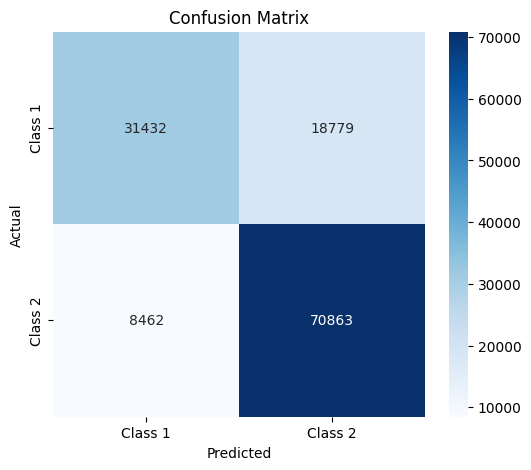

In [13]:
def evaluate_model(loader, split_name):
    pool_model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for _, (_, audio, attention_masks, dse_ids, _) in enumerate(tqdm(loader, desc=f"Eval {split_name}")):
            audio = audio.cuda(non_blocking=True).float().squeeze(1)
            attention_masks = attention_masks.cuda(non_blocking=True).float()
            dse_ids = dse_ids.cuda(non_blocking=True).float()

            logits = pool_model(audio, attention_mask=attention_masks)["disease_logits"]
            preds = torch.argmax(logits, dim=1)
            labels = np.argmax(dse_ids.cpu().numpy(), axis=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels)

    all_labels, all_preds = np.array(all_labels), np.array(all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    n_classes = cm.shape[0]
    class_labels = [f"Class {i+1}" for i in range(n_classes)]

    acc = accuracy_score(all_labels, all_preds)
    b_acc = balanced_accuracy_score(all_labels, all_preds)
    sens = np.mean([cm[i, i] / cm[i, :].sum() for i in range(n_classes) if cm[i, :].sum() > 0])
    spec = np.mean([(cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]) / (cm.sum() - cm[i, :].sum())
                    for i in range(n_classes) if (cm.sum() - cm[i, :].sum()) > 0])

    if split_name == "val":
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_labels, yticklabels=class_labels)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")

    return acc, b_acc, sens, spec

val_metrics = evaluate_model(val_loader, "val")

In [196]:
class Hook():
    def __init__(self, name, module, backward=False):
        self.name = name 
        if backward==False:
            self.hook = module.register_forward_hook(self.hook_fn)
        else:
            self.hook = module.register_backward_hook(self.hook_fn)
    
    def hook_fn(self, module, input_data, output):
        self.input = input_data
        self.output = output
    
    def close(self):
        self.hook.remove()

hookF = [Hook(name, layer) for name, layer in pool_model.named_modules()]
hookB = [Hook(name, layer,backward=True) for name, layer in pool_model.named_modules()]

In [209]:
pool_model.eval()
all_preds, all_labels = [], []

for _, (_, audio, attention_masks, dse_ids, _) in enumerate(tqdm(val_loader, desc=f"Eval {"val"}")):
    audio = audio.cuda(non_blocking=True).float().squeeze(1)
    attention_masks = attention_masks.cuda(non_blocking=True).float()
    dse_ids = dse_ids.cuda(non_blocking=True).float()
    labels = np.argmax(dse_ids.cpu().numpy(), axis=-1)

    logits = pool_model(audio, attention_mask=attention_masks)["disease_logits"]
    pred_classes = logits.argmax(dim=1)

    pool_model.zero_grad()

    target_logits = logits[torch.arange(len(pred_classes)), pred_classes].sum()
    target_logits.backward()

    # labels = logits.cpu().argmax().item()
    # logits[:, labels].backward()

    #preds = torch.argmax(logits, dim=1)
    #logits[:, preds.cpu().numpy()].backward()
    
    # all_preds.extend(preds.cpu().numpy())
    # all_labels.extend(labels)
    break

correct_indices = np.where(pred_classes.cpu().numpy() == labels)[0]

Eval val:   0%|          | 0/1012 [00:01<?, ?it/s]


Correct predictions: 106


Processing CAMs:   0%|          | 0/106 [00:00<?, ?it/s]/tmp/ipykernel_793672/4105727159.py:48: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  cam = np.maximum(cam, 0)
Processing CAMs: 100%|██████████| 106/106 [00:05<00:00, 17.73it/s]

Mean heatmap computed for class 0 (33 samples)
Mean heatmap computed for class 1 (73 samples)


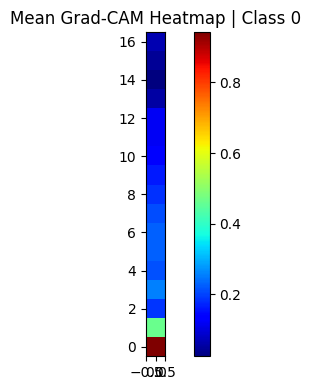

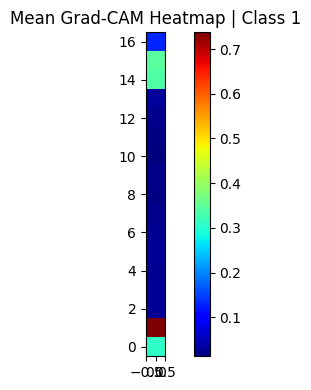

In [210]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm

pool_model.eval()

# Forward
logits = pool_model(audio, attention_mask=attention_masks)["disease_logits"]
pred_classes = logits.argmax(dim=1)
true_labels = torch.argmax(dse_ids, dim=1)

# Find correctly predicted indices
correct_indices = (pred_classes == true_labels).nonzero(as_tuple=True)[0]
print(f"Correct predictions: {len(correct_indices)}")

# Storage for CAMs per class
heatmaps_per_class = {0: [], 1: []}

for idx in tqdm(correct_indices, desc="Processing CAMs"):
    pool_model.zero_grad()
    
    # Select target class and compute gradients
    target_class = pred_classes[idx]
    logits[idx, target_class].backward(retain_graph=True)

    # Extract activations and gradients
    act, grad = None, None
    for hook in hookF:
        if hook.name == 'backbone.7.2.conv3':
            act = hook.output.detach()
    for hook in hookB:
        if hook.name == 'backbone.7.2.conv3':
            grad = hook.output[0].detach()

    # Global Average Pool gradients (Eq.1)
    pooled_grad = torch.mean(grad, dim=[0, 2, 3])

    # Weight activations
    weighted_act = act.clone()
    for i in range(weighted_act.shape[1]):
        weighted_act[:, i, :, :] *= pooled_grad[i]

    # Compute CAM (Eq.2)
    cam = torch.sum(weighted_act, dim=1).squeeze(0).cpu()[idx, :, :]
    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)

    heatmaps_per_class[int(target_class.item())].append(cam)

# Compute mean heatmap per class
mean_heatmaps = {}
for cls, maps in heatmaps_per_class.items():
    if len(maps) > 0:
        mean_heatmaps[cls] = np.mean(np.stack(maps), axis=0)
        print(f"Mean heatmap computed for class {cls} ({len(maps)} samples)")
    else:
        mean_heatmaps[cls] = None
        print(f"No samples for class {cls}")

# Visualization
for cls, mean_map in mean_heatmaps.items():
    if mean_map is None:
        continue
    plt.figure(figsize=(6, 4))
    plt.title(f"Mean Grad-CAM Heatmap | Class {cls}")
    plt.imshow(mean_map, cmap='jet', origin='lower')
    plt.colorbar()
    plt.tight_layout()
    plt.show()


Prediction:  tensor(0)
GAP gradients shape: torch.Size([2048])
Heatmap shape: torch.Size([17, 1])


/tmp/ipykernel_793672/1742479344.py:25: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  heatmap = np.maximum(heatmap, 0)


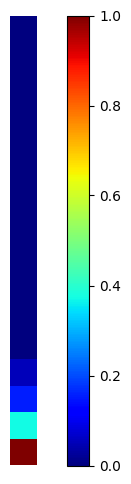

Image shape (513, 32, 1). Heatmap shape (513, 32)


/tmp/ipykernel_793672/1742479344.py:38: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  heatmap = cv2.resize(np.array(heatmap), (W, H))


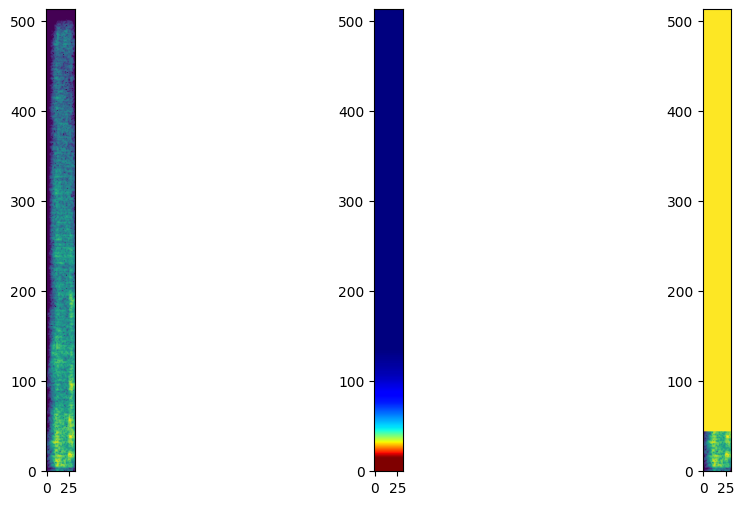

In [211]:
rand_idx = random.choice(correct_indices.tolist())
print('Prediction: ', pred_classes[rand_idx].cpu())

act, grad = None, None
for hook in hookF:
    if hook.name == 'backbone.7.2.conv3':
        act = hook.output.detach()

for hook in hookB:
    if hook.name == 'backbone.7.2.conv3':
        grad = hook.output[0].detach()

# Global Average Pool the gradients of every feature map (Eq. 1)
pooled_grad = torch.mean(grad, dim=[0, 2, 3])
print('GAP gradients shape:', pooled_grad.shape)

# Multiply every channel k of the activations by GAP gradients, that are the 'weights'
for i in range(act.shape[1]):
    act[:, i, :, :] *= pooled_grad[i]

# Sum across all k-features (Eq. 2)
heatmap = torch.sum(act, dim=1).squeeze(0).cpu()[rand_idx, :, :]

# Relu (Eq. 2)
heatmap = np.maximum(heatmap, 0)

# normalize the heatmap between 0 and 1
heatmap /= torch.max(heatmap)
print('Heatmap shape:', heatmap.shape)

# Visualize the raw CAM
plt.imshow(heatmap.numpy(), origin='lower', cmap='jet'); plt.axis('off'); plt.tight_layout(); plt.colorbar(); plt.show()

x = audio.squeeze(0).cpu().numpy()[rand_idx]
img_jpeg = np.stack([x] * 1, axis=-1) 
H, W = img_jpeg.shape[0], img_jpeg.shape[1]

heatmap = cv2.resize(np.array(heatmap), (W, H))
print(f'Image shape {img_jpeg.shape}. Heatmap shape {heatmap.shape}')

mask = heatmap > 0.4
superimposed_img = img_jpeg.copy()
superimposed_img[:,:,0] = img_jpeg[:,:,0] * mask

plt.figure(figsize=(12, 6))

plt.subplot(131)
plt.imshow(img_jpeg, origin='lower')

plt.subplot(132)
plt.imshow(heatmap, origin='lower', cmap='jet')

plt.subplot(133)
plt.imshow(superimposed_img, origin='lower')

Prediction:  tensor(1)
GAP gradients shape: torch.Size([2048])
Heatmap shape: torch.Size([17, 1])
Image shape (513, 32, 1). Heatmap shape (513, 32)


/tmp/ipykernel_793672/596360474.py:25: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  heatmap = np.maximum(heatmap, 0)
/tmp/ipykernel_793672/596360474.py:38: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  heatmap = cv2.resize(np.array(heatmap), (W, H))


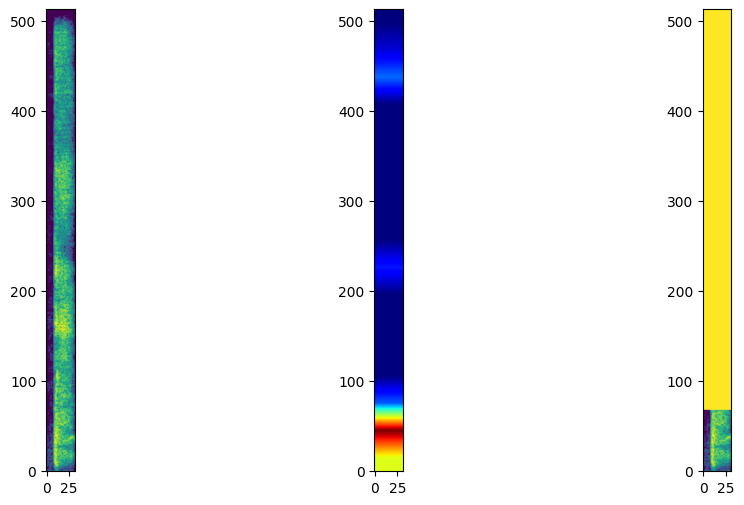

In [ ]:
rand_idx = random.choice(correct_indices.tolist())
print('Prediction: ', pred_classes[rand_idx].cpu())



# Sum across all k-features (Eq. 2)
heatmap = torch.sum(act, dim=1).squeeze(0).cpu()[rand_idx, :, :]

# Relu (Eq. 2)
heatmap = np.maximum(heatmap, 0)

# normalize the heatmap between 0 and 1
heatmap /= torch.max(heatmap)
print('Heatmap shape:', heatmap.shape)

# # Visualize the raw CAM
# plt.imshow(heatmap.numpy(), cmap='jet'); plt.axis('off'); plt.tight_layout(); plt.colorbar(); plt.show()

x = audio.squeeze(0).cpu().numpy()[rand_idx]
img_jpeg = np.stack([x] * 1, axis=-1) 
H, W = img_jpeg.shape[0], img_jpeg.shape[1]

heatmap = cv2.resize(np.array(heatmap), (W, H))
print(f'Image shape {img_jpeg.shape}. Heatmap shape {heatmap.shape}')

mask = heatmap > 0.4
superimposed_img = img_jpeg.copy()
superimposed_img[:,:,0] = img_jpeg[:,:,0] * mask

plt.figure(figsize=(12, 6))

plt.subplot(131)
plt.imshow(img_jpeg, origin='lower')

plt.subplot(132)
plt.imshow(heatmap, origin='lower', cmap='jet')

plt.subplot(133)
plt.imshow(superimposed_img, origin='lower')

In [195]:
rand_idx = random.choice(correct_indices.tolist())
print('Prediction: ', pred_classes[rand_idx].cpu())

act, grad = None, None
for hook in hookF:
    if hook.name == 'backbone.7.2.conv3':
        act = hook.output.detach()

for hook in hookB:
    if hook.name == 'backbone.7.2.conv3':
        grad = hook.output[0].detach()

# Global Average Pool the gradients of every feature map (Eq. 1)
pooled_grad = torch.mean(grad, dim=[0, 2, 3])
print('GAP gradients shape:', pooled_grad.shape)

# Multiply every channel k of the activations by GAP gradients, that are the 'weights'
for i in range(act.shape[1]):
    act[:, i, :, :] *= pooled_grad[i]

# Sum across all k-features (Eq. 2)
heatmap = torch.sum(act, dim=1).squeeze(0).cpu()[rand_idx, :, :]

# Relu (Eq. 2)
heatmap = np.maximum(heatmap, 0)

# normalize the heatmap between 0 and 1
heatmap /= torch.max(heatmap)
print('Heatmap shape:', heatmap.shape)

# # Visualize the raw CAM
# plt.imshow(heatmap.numpy(), cmap='jet'); plt.axis('off'); plt.tight_layout(); plt.colorbar(); plt.show()

Prediction:  tensor(1)
GAP gradients shape: torch.Size([2048])
Heatmap shape: torch.Size([17, 1])


/tmp/ipykernel_793672/358934585.py:25: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  heatmap = np.maximum(heatmap, 0)


Image shape (513, 32, 1). Heatmap shape (513, 32)


/tmp/ipykernel_793672/3558023967.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  heatmap = cv2.resize(np.array(heatmap), (W, H))


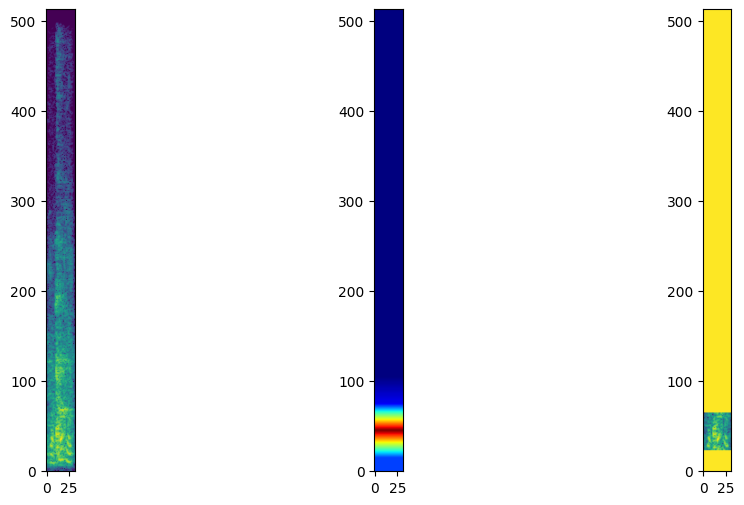

In [194]:
x = audio.squeeze(0).cpu().numpy()[0]
img_jpeg = np.stack([x] * 1, axis=-1) 
H, W = img_jpeg.shape[0], img_jpeg.shape[1]

heatmap = cv2.resize(np.array(heatmap), (W, H))
print(f'Image shape {img_jpeg.shape}. Heatmap shape {heatmap.shape}')

mask = heatmap > 0.4
superimposed_img = img_jpeg.copy()
superimposed_img[:,:,0] = img_jpeg[:,:,0] * mask

plt.figure(figsize=(12, 6))

plt.subplot(131)
plt.imshow(img_jpeg, origin='lower')

plt.subplot(132)
plt.imshow(heatmap, origin='lower', cmap='jet')

plt.subplot(133)
plt.imshow(superimposed_img, origin='lower')